# ML — La Huella Conductual

A partir de un día de datos del collar, ¿se puede reconocer de qué perro se trata? Proyecto de Machine Learning con los datos de los collares Tractive de tres perros que conviven, desde el análisis exploratorio hasta el modelo final.

**Cómo está organizado el proyecto**

- `src/notebooks/00_comprension_datos.ipynb` — qué contienen los JSON exportados de los collares, cómo se pasan a tablas y el diccionario de datos.
- `main.ipynb` — este notebook: EDA, modelado y evaluación.

## Paso 1: Entendiendo el problema

**Problema de negocio.** Los dueños y el veterinario quieren detectar a tiempo cambios en el comportamiento de cada perro. Un aviso personalizado ("hoy cherry no se comporta como de costumbre") solo tiene sentido si los datos del collar son lo bastante propios de cada perro como para darle su propia referencia. Si los perros se comportaran de forma parecida, bastaría con un umbral común.

**Pregunta que responde el modelo:** a partir de un día de datos del collar, ¿se puede reconocer de qué perro se trata? Si la respuesta es sí, cada perro tiene una referencia propia, y las variables que más usa el modelo son las señales que conviene vigilar.

**Objetivo de modelado:** clasificación supervisada con tres clases. La target es `perro` (cherry, coco o plum) y cada fila es un día de un perro.

**Plan de acción**

| Resultado del modelo | Decisión |
|---|---|
| Reconoce bien a cada perro en días que no ha visto | Avisos personalizados, con la referencia de cada perro y vigilando las señales más importantes del modelo |
| No consigue distinguirlos | Avisos con un umbral común para los tres |

**Uso futuro.** Un día en que un perro no se parezca a sí mismo según el modelo podría marcarse como atípico. Validarlo exigiría un historial veterinario que hoy no existe, así que queda fuera de este proyecto.

**¿Por qué Machine Learning?** Las señales de un perro cambian mucho de un día a otro, así que es probable que una sola no baste para reconocerlo. Un modelo puede aprender a combinar varias. El EDA comprueba antes si combinadas separan mejor a los perros.

**Alcance: tres perros.** Cherry, coco y plum llevan el mismo modelo de collar. El de kiwi, el cuarto perro de la casa, es de otro modelo y no tiene sensor de ladridos, así que queda fuera para que el modelo no aprenda a reconocer el dispositivo en lugar del perro. Cada perro ha llevado siempre su propio collar.

### Hipótesis del EDA

El EDA contrasta cuatro hipótesis, cada una con consecuencias para el modelo o para los avisos:

| | Hipótesis | Si se confirma | Si se refuta |
|---|---|---|---|
| **H1** | La frecuencia cardíaca (FC) y respiratoria (FR) en reposo difieren entre los perros | Son candidatas principales a features | Buscar la huella en la actividad y los ladridos |
| **H2** | En los días más calurosos los perros están menos activos | Tener en cuenta la época del año al evaluar con días posteriores y en los avisos | No hace falta tener en cuenta la época del año |
| **H3** | Los perros que conviven ladran en las mismas franjas horarias más de lo esperable por azar | Parte de los ladridos responde a la casa: comprobar que, aun así, distinguen a cada perro | Los ladridos son una señal propia de cada perro |
| **H4** | Los perros están más activos en fin de semana, cuando los dueños están en casa | En los avisos, comparar cada día con los del mismo tipo (laborable o fin de semana) | No hace falta separar laborables y fines de semana |

> **Nota metodológica:** antes de formular las hipótesis se revisó qué contenían los datos (`00_comprension_datos.ipynb`). Para no sesgar el análisis, las hipótesis hablan de mecanismos generales y no de perros o valores concretos vistos en esa revisión.

**Datos.** Tres datasets generados a partir de los exports de los collares con `src/utils/data_loader.py`: uno con una fila por perro y día, otro con los ladridos por franjas de 30 minutos y otro con la actividad por hora. Ninguno contiene coordenadas.

## Paso 2: Carga de datos y tabla de variables

In [1]:
import pickle
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from src.utils.bootcampviztools import (pinta_distribucion_categoricas, plot_combined_graphs,
                                        plot_grouped_histograms)

# seaborn 0.13 usa una opción de matplotlib 3.11 marcada como obsoleta; no afecta a los gráficos
warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid")

Se cargan los tres datasets y se quedan los días de cherry, coco y plum:

In [2]:
TARGET = "perro"
PERROS = ["cherry", "coco", "plum"]

crudo = pd.read_csv("src/data_sample/diario_perros.csv", parse_dates=["fecha"])
franjas = pd.read_csv("src/data_sample/ladridos_30min.csv", parse_dates=["fecha"])
horaria = pd.read_csv("src/data_sample/actividad_horaria.csv", parse_dates=["fecha"])
print("Con los cuatro perros -> diario:", crudo.shape, "| franjas:", franjas.shape, "| horaria:", horaria.shape)

crudo = crudo[crudo["perro"] != "kiwi"].copy()
horaria = horaria[horaria["perro"] != "kiwi"]
print("Sin kiwi -> diario:", crudo.shape, "| franjas:", franjas.shape, "| horaria:", horaria.shape)
crudo.head()

Con los cuatro perros -> diario: (898, 24) | franjas: (27312, 4) | horaria: (21552, 9)
Sin kiwi -> diario: (570, 24) | franjas: (27312, 4) | horaria: (13680, 9)


,perro,fecha,min_reposo,min_calma,min_activo,min_intenso,min_sin_datos,min_otros,ladridos_total,ladridos_franjas,...,fc_n,fr_media,fr_min,fr_max,fr_n,temp_disp_media,temp_disp_max,dia_semana,es_finde,mes
0,cherry,2026-02-22,240.183333,6.416667,7.950000,0.0,1185.450000,0.0,6.0,2.0,...,22.0,9.471429,7.0,14.0,70.0,21.909091,28,Sunday,True,2
1,cherry,2026-02-23,888.233333,85.266667,117.700000,0.0,348.800000,0.0,149.0,11.0,...,76.0,8.460938,5.0,20.0,128.0,27.000000,35,Monday,False,2
2,cherry,2026-02-24,933.016667,67.616667,108.600000,0.0,330.766667,0.0,289.0,15.0,...,71.0,7.847826,5.0,14.0,138.0,27.684211,32,Tuesday,False,2
3,cherry,2026-02-25,1014.400000,50.433333,87.466667,0.0,287.700000,0.0,565.0,19.0,...,86.0,7.922619,4.0,16.0,168.0,26.666667,35,Wednesday,False,2
4,cherry,2026-02-26,901.866667,79.583333,116.683333,0.0,341.866667,0.0,351.0,10.0,...,51.0,7.909677,5.0,16.0,155.0,27.333333,36,Thursday,False,2


Quedan 570 días de los tres perros. El dataset de ladridos por franja no cambia, porque kiwi no aparece en él.

**Tipos de dato**

In [3]:
crudo.dtypes

perro                            str
fecha                 datetime64[us]
min_reposo                   float64
min_calma                    float64
min_activo                   float64
min_intenso                  float64
min_sin_datos                float64
min_otros                    float64
ladridos_total               float64
ladridos_franjas             float64
ladridos_max_30min           float64
fc_media                     float64
fc_min                       float64
fc_max                       float64
fc_n                         float64
fr_media                     float64
fr_min                       float64
fr_max                       float64
fr_n                         float64
temp_disp_media              float64
temp_disp_max                  int64
dia_semana                       str
es_finde                        bool
mes                            int64
dtype: object

Las fechas se leen como fechas, las señales como números y `perro` como texto. Los conteos de ladridos salen como decimales porque un nulo obliga a pandas a usar `float`. No hace falta convertir nada.

### Tabla de variables

El diccionario completo de los tres datasets está en `00_comprension_datos.ipynb`, §8. Esta tabla resume qué papel tiene cada columna del dataset diario:

| Variable | Tipo | Papel | Motivo |
|---|---|---|---|
| `perro` | categórica | **target** | lo que se quiere predecir |
| `fecha` | fecha | ordenar y dividir los datos | es la misma para los tres perros cada día |
| `min_reposo`, `min_calma`, `min_activo`, `min_intenso` | numérica | candidata, como porcentaje | minutos del día en cada categoría de actividad; en la limpieza se pasan a porcentaje del tiempo medido |
| `fc_media`, `fc_min`, `fc_max` | numérica | candidata | frecuencia cardíaca en reposo |
| `fr_media`, `fr_min`, `fr_max` | numérica | candidata | frecuencia respiratoria en reposo |
| `ladridos_total`, `ladridos_franjas`, `ladridos_max_30min` | numérica | candidata | los tres collares tienen sensor de ladridos |
| `min_otros` | numérica | descartada | categoría casi inexistente (`00`, §4) |
| `min_sin_datos`, `fc_n`, `fr_n` | numérica | calidad del dato | describen cuánto midió el collar, no al perro; `min_sin_datos` sirve para filtrar días |
| `temp_disp_media`, `temp_disp_max` | numérica | contexto (H2) | cada collar envía sus lecturas de temperatura en distinta cantidad y a horas distintas, así que la media diaria no es comparable entre perros (`00`, §6) |
| `dia_semana`, `es_finde`, `mes` | categórica | contexto (H4) | son iguales para los tres perros cada día: no ayudan a distinguirlos |

Las candidatas se revisan en el EDA y la selección final se hace en el Paso 8.

## Paso 3: Limpieza

Se comprueba que los datos cumplen lo que dice el diccionario y se decide qué días usar. Son reglas fijas que se aplican a cada día por separado, como "al menos medio día medido", así que aplicarlas antes de dividir en train y test no traslada información del test a train.

### 3.1 Duplicados y días que faltan

In [4]:
print("Filas duplicadas (mismo perro y día):", crudo.duplicated(subset=["perro", "fecha"]).sum())

for perro in PERROS:
    datos_perro = crudo[crudo["perro"] == perro]
    dias_posibles = (datos_perro["fecha"].max() - datos_perro["fecha"].min()).days + 1
    print(f"{perro}: del {datos_perro['fecha'].min().date()} al {datos_perro['fecha'].max().date()} | "
          f"{len(datos_perro)} días registrados de {dias_posibles} posibles")

Filas duplicadas (mismo perro y día): 0
cherry: del 2026-02-22 al 2026-09-09 | 200 días registrados de 200 posibles
coco: del 2026-03-26 al 2026-09-10 | 169 días registrados de 169 posibles
plum: del 2026-02-22 al 2026-09-10 | 201 días registrados de 201 posibles


No hay duplicados ni faltan días. Coco empezó a llevar el collar un mes después que cherry y plum.

### 3.2 Nulos

In [5]:
nulos = crudo.isna().sum()
print(nulos[nulos > 0])

crudo["min_medidos"] = 1440 - crudo["min_sin_datos"]
print("\nDía con nulos:")
print(crudo[crudo["ladridos_total"].isna()][["perro", "fecha", "min_medidos"]])

ladridos_total        1
ladridos_franjas      1
ladridos_max_30min    1
dtype: int64

Día con nulos:
    perro      fecha  min_medidos
722  plum 2026-03-19   301.466667


Solo hay un día con nulos, en las tres columnas de ladridos de plum. Ese día el collar apenas midió unas horas, así que lo elimina el filtro del apartado siguiente y no hace falta rellenarlo.

### 3.3 ¿Cuánto midió el collar cada día?

Cada día tiene 1.440 minutos, pero parte de ese tiempo el collar no mide (carga, falta de cobertura). Si un día apenas se midió, sus cifras no son fiables.

Además, el loader ya ha convertido en "sin datos" unos bloques imposibles de actividad intensa, de hasta 13 horas seguidas (`00_comprension_datos.ipynb`, §4.1).

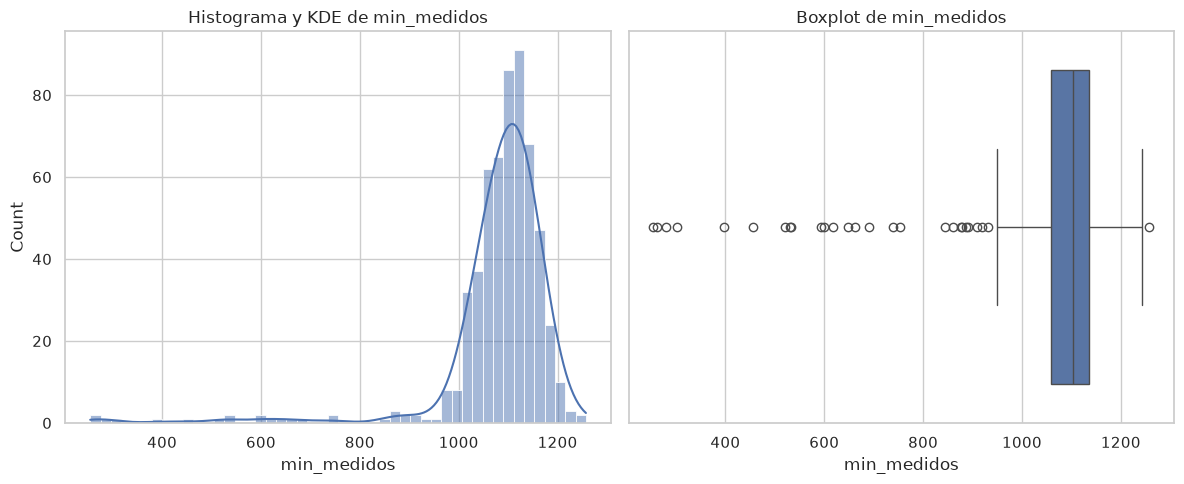

count     570.0
mean     1081.0
std       117.0
min       255.0
25%      1059.0
50%      1103.0
75%      1135.0
max      1257.0
Name: min_medidos, dtype: float64


In [6]:
plot_combined_graphs(crudo, ["min_medidos"])
print(crudo["min_medidos"].describe().round(0))

La mayoría de días está bien medida (la mediana ronda los 1.100 minutos), pero hay una cola de días con muchos huecos. Se fija un criterio sencillo: **un día cuenta si el collar midió al menos medio día (720 minutos)**.

In [7]:
MIN_MEDIDOS = 720

descartados = crudo[crudo["min_medidos"] < MIN_MEDIDOS]
print(f"Días descartados: {len(descartados)} de {len(crudo)} ({100 * len(descartados) / len(crudo):.1f} %)\n")
print(descartados[["perro", "fecha", "min_medidos"]].sort_values("min_medidos"))

df = crudo[crudo["min_medidos"] >= MIN_MEDIDOS].copy()

Días descartados: 15 de 570 (2.6 %)

      perro      fecha  min_medidos
0    cherry 2026-02-22   254.550000
697    plum 2026-02-22   261.283333
200    coco 2026-03-26   280.150000
722    plum 2026-03-19   301.466667
777    plum 2026-05-13   396.283333
723    plum 2026-03-20   455.433333
334    coco 2026-08-07   521.233333
843    plum 2026-07-18   531.650000
108  cherry 2026-06-10   533.066667
249    coco 2026-05-14   592.916667
23   cherry 2026-03-17   600.366667
271    coco 2026-06-05   617.400000
894    plum 2026-09-07   647.783333
704    plum 2026-03-01   662.433333
793    plum 2026-05-29   690.050000


Se descartan 15 días, un 2,6 %. Entre ellos están el primer día de cada perro, en el que el collar solo midió unas horas, y el día con nulos de plum.

### 3.4 De minutos a porcentaje del tiempo medido

Las columnas `min_*` reparten los 1.440 minutos del día, así que un día con muchas horas sin datos tendrá a la fuerza menos minutos de reposo. Para comparar días y perros se usa el **porcentaje del tiempo realmente medido**.

In [8]:
df["pct_reposo"] = 100 * df["min_reposo"] / df["min_medidos"]
df["pct_calma"] = 100 * df["min_calma"] / df["min_medidos"]
df["pct_activo"] = 100 * df["min_activo"] / df["min_medidos"]
df["pct_intenso"] = 100 * df["min_intenso"] / df["min_medidos"]

cherry = df[df["perro"] == "cherry"]
print("Correlación con los minutos sin datos (cherry):")
print("  minutos de reposo:   ", round(cherry["min_reposo"].corr(cherry["min_sin_datos"]), 2))
print("  porcentaje de reposo:", round(cherry["pct_reposo"].corr(cherry["min_sin_datos"]), 2))

Correlación con los minutos sin datos (cherry):
  minutos de reposo:    -0.94
  porcentaje de reposo: -0.62


El porcentaje reduce la dependencia del tiempo sin datos (de −0,94 a −0,62), aunque **no la elimina del todo**. Aun así, es la forma más justa de comparar días con distinto tiempo medido.

### 3.5 Ventana común

Para comparar a los perros en las mismas fechas y que las tres clases queden equilibradas, se usan solo los días en los que los tres tienen datos:

In [9]:
VENTANA_INICIO = "2026-03-26"   # primer día con datos de los tres perros
VENTANA_FIN = "2026-09-09"      # último día con datos de los tres perros

datos = df[(df["fecha"] >= VENTANA_INICIO) & (df["fecha"] <= VENTANA_FIN)].copy()

print("Días que quedan fuera de la ventana:")
print(df[(df["fecha"] < VENTANA_INICIO) | (df["fecha"] > VENTANA_FIN)]["perro"].value_counts())
print("\nDías por perro en la ventana:")
print(datos["perro"].value_counts())
print("\nValores nulos:", datos.isna().sum().sum())

Días que quedan fuera de la ventana:
perro
cherry    30
plum      29
coco       1
Name: count, dtype: int64

Días por perro en la ventana:
perro
cherry    167
coco      164
plum      164
Name: count, dtype: int64

Valores nulos: 0


Quedan 495 días, repartidos de forma equilibrada entre los tres perros y sin valores nulos.

## Paso 4: División en train y test

Los datos se ordenan por fecha y se cortan el 1 de agosto: lo anterior es train, y agosto y septiembre son test. No se usa una división aleatoria porque:

- **El modelo se usaría con días futuros**, así que se prueba igual: aprende del pasado y se evalúa con días posteriores.
- **Los días seguidos de un mismo perro se parecen.** Con una división aleatoria, el test tendría días casi idénticos a otros de train y el resultado saldría mejor de lo que es.

El test cae a finales de verano. Si el comportamiento cambia con la época del año (H2), el resultado en test podría bajar algo por eso.

In [10]:
datos = datos.sort_values(["fecha", "perro"]).reset_index(drop=True)

CORTE = "2026-08-01"
train_set = datos[datos["fecha"] < CORTE]
test_set = datos[datos["fecha"] >= CORTE]

print(f"train: {len(train_set)} días, del {train_set['fecha'].min().date()} al {train_set['fecha'].max().date()}")
print(f"test:  {len(test_set)} días, del {test_set['fecha'].min().date()} al {test_set['fecha'].max().date()}")
print(f"proporción de test: {100 * len(test_set) / len(datos):.1f} %")
pd.DataFrame({"train": train_set["perro"].value_counts(), "test": test_set["perro"].value_counts()})

train: 377 días, del 2026-03-26 al 2026-07-31
test:  118 días, del 2026-08-01 al 2026-09-09
proporción de test: 23.8 %


,train,test
perro,,
cherry,127,40
coco,125,39
plum,125,39


El corte deja 377 días de train y 118 de test (un 23,8 %), con los tres perros equilibrados en ambos.

**A partir de aquí, todo el EDA y todas las decisiones del modelo se hacen solo con train.** Los datasets de ladridos por franja y de actividad por hora se cruzan con los días de train cuando se usan.

## Paso 5: Análisis univariante

Todo el EDA usa solo `train_set`. Antes de analizar conviene priorizar las variables:

| Papel | Columnas |
|---|---|
| **Señales de comportamiento** | `pct_reposo`, `pct_calma`, `pct_activo`, `pct_intenso`, `ladridos_total`, `fc_media`, `fr_media` |
| Variantes de las anteriores | `fc_min`, `fc_max`, `fr_min`, `fr_max`, `ladridos_franjas`, `ladridos_max_30min` |
| Contexto | `fecha`, `es_finde`, `mes`, `temp_disp_media` |

⚠️ `train_set` mezcla a los tres perros, así que aquí se buscan sobre todo **problemas en los datos**. La comparación entre perros llega en el bivariante.

In [11]:
SENALES = ["pct_reposo", "pct_calma", "pct_activo", "pct_intenso", "ladridos_total", "fc_media", "fr_media"]
VARIANTES = ["fc_min", "fc_max", "fr_min", "fr_max", "ladridos_franjas", "ladridos_max_30min"]
CANDIDATAS = SENALES + VARIANTES

### 5.1 Target y variables categóricas

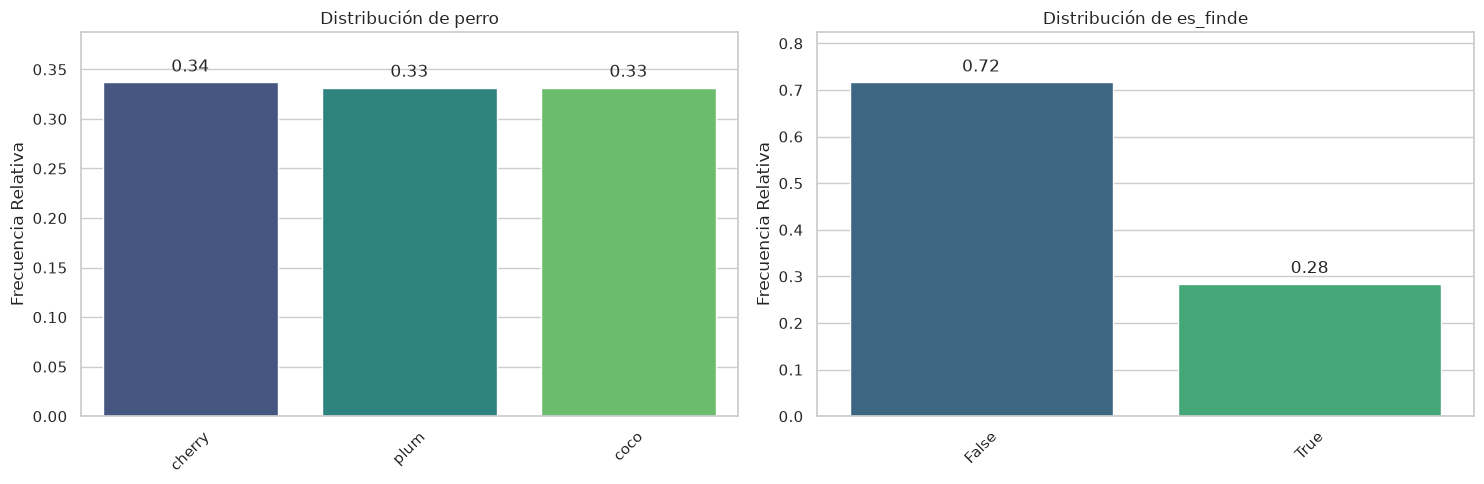

In [12]:
pinta_distribucion_categoricas(train_set, ["perro", "es_finde"], relativa=True, mostrar_valores=True)

Las tres clases están equilibradas, con un tercio de los días cada una, así que **no hace falta ninguna técnica de balanceo**. Algo más de una cuarta parte de los días son fin de semana, lo esperable (2 de cada 7).

### 5.2 Tendencia central y dispersión

In [13]:
resumen = train_set[SENALES].describe().T
resumen["media - mediana"] = resumen["mean"] - resumen["50%"]
resumen.round(2)

,count,mean,std,min,25%,50%,75%,max,media - mediana
pct_reposo,377.0,85.58,3.07,68.30,83.90,85.75,87.54,92.64,-0.17
pct_calma,377.0,3.95,1.11,1.36,3.05,3.91,4.71,6.82,0.03
pct_activo,377.0,10.14,2.18,2.81,8.55,10.11,11.53,17.79,0.03
pct_intenso,377.0,0.26,1.53,0.00,0.00,0.00,0.00,12.62,0.26
ladridos_total,377.0,133.51,156.65,0.00,9.00,83.00,207.00,1054.00,50.51
fc_media,377.0,61.59,4.59,53.78,58.31,60.48,64.32,83.42,1.12
fr_media,377.0,10.16,1.98,6.42,8.81,9.69,11.50,17.84,0.47


- En `ladridos_total` la media (133,51) supera con mucho a la mediana (83): unos pocos días con muchísimos ladridos tiran de la media hacia arriba.
- En `fc_media` y `fr_media` la media supera algo a la mediana (1,12 y 0,47), y en `pct_intenso` la mediana es 0.
- En los demás porcentajes de actividad, media y mediana casi coinciden.

### 5.3 Distribuciones

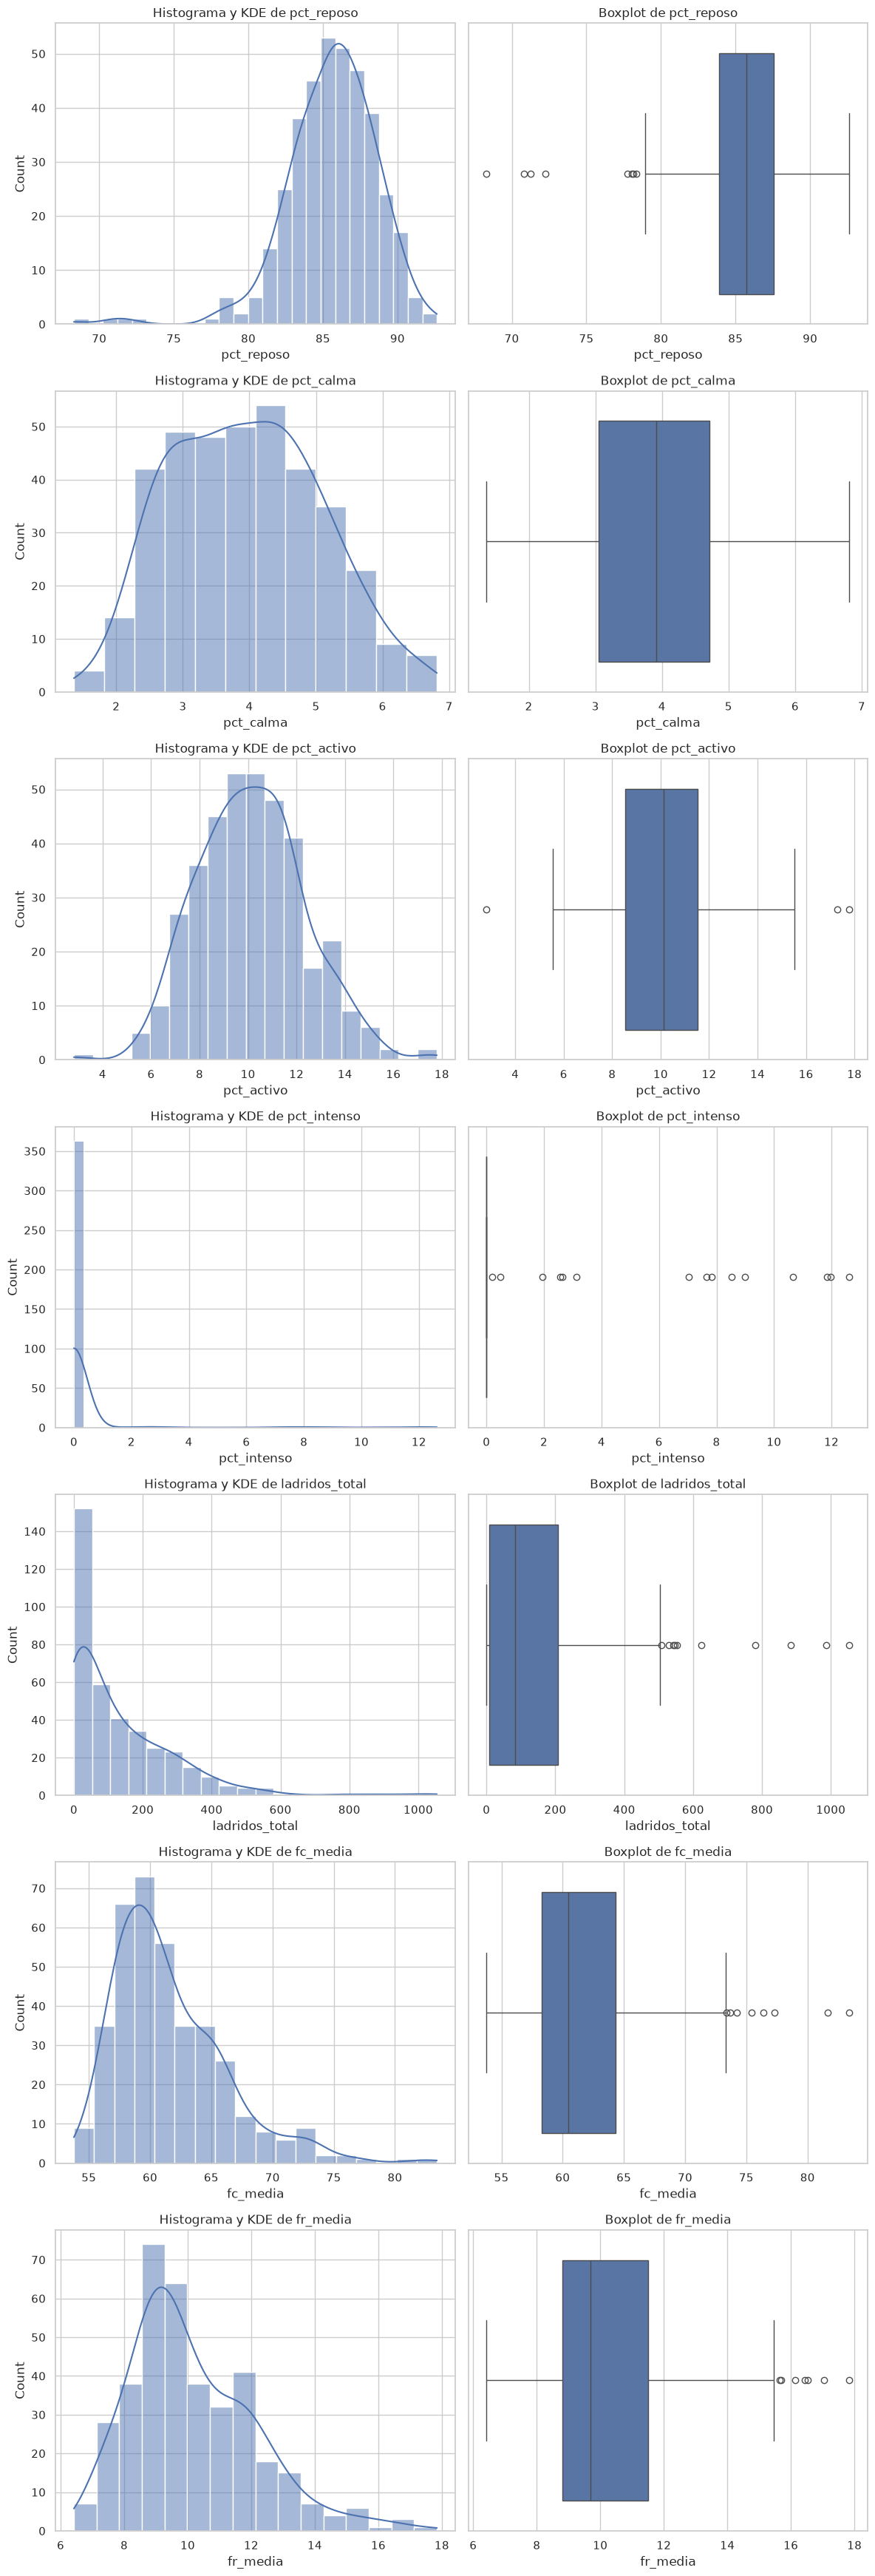

In [14]:
plot_combined_graphs(train_set, SENALES)

- `ladridos_total` tiene una cola larga hacia la derecha y un pico junto a cero.
- `pct_intenso` es casi una única barra en cero.
- `fc_media` y `fr_media` tienen cola hacia valores altos, y `pct_reposo`, unos pocos días con mucho menos reposo de lo habitual.
- `pct_calma` tiene una joroba ancha y achatada, una pista de que puede mezclar grupos distintos.
- `pct_activo` tiene una sola joroba, pero eso **no significa que los tres perros sean iguales**: se comprueba en el bivariante.

### 5.4 Variables casi constantes

In [15]:
print("Días con pct_intenso = 0:", (train_set["pct_intenso"] == 0).sum(), "de", len(train_set))
print("Días con algo de actividad intensa, por perro:")
print(train_set[train_set["pct_intenso"] > 0]["perro"].value_counts())

print("\nValores que toma fc_min y número de días con cada uno:")
print(train_set["fc_min"].value_counts().sort_index())
print("\n% de días en que fc_min vale 51:")
print(train_set.groupby("perro")["fc_min"].apply(lambda valores: round(100 * (valores == 51).mean())))

Días con pct_intenso = 0: 362 de 377
Días con algo de actividad intensa, por perro:
perro
plum      6
cherry    6
coco      3
Name: count, dtype: int64

Valores que toma fc_min y número de días con cada uno:
fc_min
42.0     54
44.0     12
46.0      8
48.0      2
50.0      7
51.0    255
52.0     27
53.0      9
54.0      3
Name: count, dtype: int64

% de días en que fc_min vale 51:
perro
cherry    74
coco      59
plum      70
Name: fc_min, dtype: int64


- `pct_intenso` es cero en 362 de 377 días, y los días restantes se reparten entre los tres perros, con entre 3 y 6 cada uno. No sirve para compararlos.
- `fc_min` solo toma unos pocos valores, y vale 51 entre el 59 % y el 74 % de los días en los tres perros. Como casi siempre marca lo mismo, aporta muy poca información.

### 5.5 Valores extremos

Se buscan dentro de cada perro, con la regla de 1,5 veces el rango intercuartílico: si los perros tienen niveles distintos, lo normal en uno parecería extremo en otro.

In [16]:
extremos = {}
for perro in PERROS:
    datos_perro = train_set[train_set["perro"] == perro][CANDIDATAS]
    q1 = datos_perro.quantile(0.25)
    q3 = datos_perro.quantile(0.75)
    rango = q3 - q1
    extremos[perro] = ((datos_perro < q1 - 1.5 * rango) | (datos_perro > q3 + 1.5 * rango)).sum()
pd.DataFrame(extremos)

,cherry,coco,plum
pct_reposo,2,4,2
pct_calma,1,2,0
pct_activo,1,1,0
pct_intenso,6,3,6
ladridos_total,5,2,15
fc_media,5,2,2
fr_media,2,2,5
fc_min,33,51,38
fc_max,0,3,13
fr_min,0,1,4


La mayoría de variables tienen pocos valores extremos, con dos casos que destacan:

- **`fc_min` acumula muchos**, entre 33 y 51 por perro, porque casi siempre marca 51 (5.4) y cualquier otro valor sale como extremo. En `pct_intenso` pasa lo mismo: sus extremos son justo los pocos días con algo de actividad intensa.
- **Plum tiene más extremos que los otros dos** en `ladridos_total` (15) y en `fc_max` (13).

¿Son errores de medida?

In [17]:
fuera_de_rango = train_set[(train_set["fc_media"] > 140) | (train_set["fr_media"] > 35)]
print("Días con FC media > 140 o FR media > 35:", len(fuera_de_rango))

print("\nMáximos puntuales de cada día:")
print(train_set[["fc_max", "fr_max"]].describe().round(1))

print("\nLos 5 días con la FR media más alta:")
print(train_set.nlargest(5, "fr_media")[["perro", "fecha", "fr_media"]])

Días con FC media > 140 o FR media > 35: 0

Máximos puntuales de cada día:
       fc_max  fr_max
count   377.0   377.0
mean     97.9    25.7
std      24.9     9.1
min      60.0    10.0
25%      80.0    19.0
50%      92.0    24.0
75%     107.0    32.0
max     180.0    70.0

Los 5 días con la FR media más alta:
      perro      fecha   fr_media
350  cherry 2026-07-23  17.841584
365  cherry 2026-07-28  17.037559
374  cherry 2026-07-31  16.526178
352    plum 2026-07-23  16.438679
353  cherry 2026-07-24  16.142857


Ninguna media diaria supera los valores orientativos de un perro adulto en reposo (FC de hasta 140 lpm y FR de hasta 35 rpm). Hay picos puntuales altos (`fc_max` llega a 180 lpm), pero son momentos aislados, no medias del día. Y las cinco FR medias más altas son de finales de julio, en pleno verano, lo que encaja con el calor más que con errores de medida.

**No se elimina ningún dato por ser extremo.**

### 5.6 ¿Sobra alguna variante?

Si una variable está casi perfectamente correlacionada con otra, no aporta información nueva.

In [18]:
pares = [("ladridos_total", "ladridos_max_30min"), ("ladridos_total", "ladridos_franjas"),
         ("fr_media", "fr_max"), ("fr_media", "fr_min"),
         ("fc_media", "fc_min"), ("fc_media", "fc_max"),
         ("pct_reposo", "pct_activo")]
for variable_1, variable_2 in pares:
    print(f"{variable_1} vs {variable_2}: r = {train_set[variable_1].corr(train_set[variable_2]):.2f}")

ladridos_total vs ladridos_max_30min: r = 0.89
ladridos_total vs ladridos_franjas: r = 0.70
fr_media vs fr_max: r = 0.61
fr_media vs fr_min: r = 0.62
fc_media vs fc_min: r = 0.02
fc_media vs fc_max: r = 0.20
pct_reposo vs pct_activo: r = -0.79


| Variable | r | Decisión |
|---|---|---|
| `ladridos_max_30min` | 0,89 con el total | **Fuera**: repite casi la misma información que `ladridos_total` |
| `ladridos_franjas` | 0,70 con el total | Se queda: mide cómo se reparten los ladridos en el día |
| `fr_max`, `fr_min` | 0,61 y 0,62 con la media | Se quedan |
| `fc_max`, `fc_min` | 0,20 y 0,02 con la media | Información distinta de la media (aunque `fc_min` es casi constante, 5.4) |
| `pct_reposo` | −0,79 con `pct_activo` | Los porcentajes reparten el mismo tiempo medido: no conviene usarlos todos a la vez |

### 5.7 Conclusiones del univariante

1. **Las clases están equilibradas:** no hace falta balanceo.
2. **No hay valores imposibles.** Los extremos tienen explicación y no se elimina ningún dato.
3. **`pct_intenso` y `fc_min` casi nunca cambian**, y **`ladridos_max_30min` repite `ladridos_total`**: las tres son candidatas a descartar.
4. **`ladridos_total` tiene un pico junto a cero y `pct_calma` una joroba ancha.** Hay que ver si se deben a perros concretos.